In [1]:
# Imports and database connection setup

import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection engine ready.")

Connection engine ready.


In [2]:
# Loading churn features from Postgres into a DataFrame

query = """
SELECT 
    s.customer_id,
    s.plan_name,
    EXTRACT(YEAR FROM AGE(COALESCE(s.end_date, CURRENT_DATE), s.start_date)) * 12 +
    EXTRACT(MONTH FROM AGE(COALESCE(s.end_date, CURRENT_DATE), s.start_date)) AS tenure_months,
    s.mrr,
    COALESCE(ga.total_events, 0) AS total_events,
    COALESCE(ga.active_days, 0) AS active_days,
    COALESCE(crm.total_sent, 0) AS crm_emails_sent,
    COALESCE(crm.total_opened, 0) AS crm_emails_opened,
    COALESCE(crm.total_clicked, 0) AS crm_emails_clicked,
    CASE WHEN c.customer_type = 'both' THEN 1 ELSE 0 END AS also_ecommerce,
    CASE WHEN s.status = 'cancelled' THEN 1 ELSE 0 END AS churned
FROM subscriptions s
INNER JOIN customers c ON s.customer_id = c.customer_id
LEFT JOIN (
    SELECT customer_id, COUNT(*) AS total_events, COUNT(DISTINCT event_date) AS active_days
    FROM ga4_events GROUP BY customer_id
) ga ON c.customer_id = ga.customer_id
LEFT JOIN (
    SELECT customer_id, COUNT(*) AS total_sent, SUM(opened::int) AS total_opened, SUM(clicked::int) AS total_clicked
    FROM crm_engagement GROUP BY customer_id
) crm ON c.customer_id = crm.customer_id
WHERE s.status IN ('active', 'cancelled');
"""

churn_features = pd.read_sql(query, engine)
print(f"Loaded {len(churn_features)} rows.")
churn_features.head()

Loaded 8472 rows.


,customer_id,plan_name,tenure_months,mrr,total_events,active_days,crm_emails_sent,crm_emails_opened,crm_emails_clicked,also_ecommerce,churned
0,1,Basic,5.0,15.0,3,2,6,3,1,0,0
1,2,Basic,13.0,15.0,16,11,12,6,0,1,0
2,4,Pro,6.0,45.0,4,2,12,6,2,0,0
3,8,Basic,22.0,15.0,7,3,12,6,2,0,0
4,11,Basic,20.0,15.0,13,5,11,6,1,0,0


In [4]:
# One-hot encode plan_name, defining features/target, split train/test

from sklearn.model_selection import train_test_split

# One-hot encode plan_name: turns 'Basic'/'Pro'/'Enterprise' into
# separate 0/1 columns. drop_first=True avoids a redundant column
# (if it's not Pro and not Enterprise, we already know it's Basic).
churn_features_encoded = pd.get_dummies(churn_features, columns=['plan_name'], drop_first=True)

# Define which columns are predictive features vs. the target we want to predict.
# customer_id is just an identifier (not predictive), and 'churned' is
# the answer itself, so both are excluded from the feature list.
feature_columns = [col for col in churn_features_encoded.columns if col not in ['customer_id', 'churned']]

X = churn_features_encoded[feature_columns]   # features (inputs)
y = churn_features_encoded['churned']         # target (what we're predicting)

# Split: 80% train, 20% test.
# random_state=42 makes the split reproducible (same split every run).
# stratify=y keeps the churn rate consistent between train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} rows, churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set: {len(X_test)} rows, churn rate: {y_test.mean()*100:.1f}%")

Training set: 6777 rows, churn rate: 26.5%
Test set: 1695 rows, churn rate: 26.5%


In [5]:
# Training a logistic regression model

from sklearn.linear_model import LogisticRegression

churn_model = LogisticRegression(max_iter=1000)
churn_model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [6]:
# Evaluating the model on the held-out test set

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Generate predictions on the TEST set — data the model has never seen
churn_predictions = churn_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, churn_predictions)*100:.1f}%")
print("\nClassification report:")
print(classification_report(y_test, churn_predictions, target_names=['Not Churned', 'Churned']))

print("Confusion matrix:")
print(confusion_matrix(y_test, churn_predictions))

Accuracy: 74.7%

Classification report:
              precision    recall  f1-score   support

 Not Churned       0.76      0.96      0.85      1245
     Churned       0.58      0.16      0.26       450

    accuracy                           0.75      1695
   macro avg       0.67      0.56      0.55      1695
weighted avg       0.71      0.75      0.69      1695

Confusion matrix:
[[1192   53]
 [ 376   74]]


**From the results above:**

Overall accuracy: 74.7%, looks decent at a glance

But recall for "Churned" is only 0.16 meaning that the model correctly identifies only 16% of actual churners (74 out of 450, per the confusion matrix's bottom row: [376 missed, 74 caught])

It's essentially defaulting to predicting "not churned" most of the time, because that's the "safe" statistical bet when one class dominates (73.5% of the data)

Logistic regression, by default, tries to minimize overall errors, and since "not churned" is the majority class, the easiest way to minimize errors is to just lean heavily toward predicting that. It's not that the model I built is "bad", it's doing exactly what it's mathematically told to do, we just told it the wrong thing to optimize for.

**To fix, we either:**

- *Improve the features:* The current features may not separate churners from non-churners well enough. More/better engineered features (e.g. recent vs. lifetime engagement trends) could genuinely help. Going to add recency-based features (e.g. engagement in last 30 days vs. earlier), revisit which signals are most predictive. It's more work, but addresses the root cause rather than just re-weighting

- *Do class weighting:* Tell logistic regression to penalize missing a churner more heavily than misclassifying a non-churner, by setting class_weight='balanced'. For me, this is the simplest fix, one parameter change. Basically,re-run LogisticRegression(class_weight='balanced'), re-evaluate recall/precision trade-off. No new data or features needed

- *Adjust the Decision Threshold:* By default the model predicts 'churned' only if probability > 50%. Lowering that threshold (e.g. to 30%) catches more true churners, at the cost of more false alarms. I can use predict_proba() instead of predict(). Manually pick a threshold based on business tolerance for false alarms.

In [7]:
# starting with the simplest: class weighting
# class_weight='balanced' to address the class imbalance problem 

churn_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
churn_model_balanced.fit(X_train, y_train)

churn_predictions_balanced = churn_model_balanced.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, churn_predictions_balanced)*100:.1f}%")
print("\nClassification report:")
print(classification_report(y_test, churn_predictions_balanced, target_names=['Not Churned', 'Churned']))

print("Confusion matrix:")
print(confusion_matrix(y_test, churn_predictions_balanced))

Accuracy: 65.0%

Classification report:
              precision    recall  f1-score   support

 Not Churned       0.85      0.63      0.73      1245
     Churned       0.41      0.70      0.52       450

    accuracy                           0.65      1695
   macro avg       0.63      0.67      0.62      1695
weighted avg       0.74      0.65      0.67      1695

Confusion matrix:
[[784 461]
 [133 317]]


Recall on "Churned" jumped from 0.16 → 0.70, correctly catching 317 of 450 real churners (up from just 74 before)
Precision dropped from 0.58 → 0.41 - more false alarms (461 non-churners incorrectly flagged), and overall accuracy dropped (65.0% vs 74.7%)

Overall accuracy went down, accuracy was misleadingly high before precisely because the model was ignoring churners

**Why this is the right trade-off for churn specifically:** Missing a churner (false negative) means losing a paying customer with zero chance to intervene. Flagging a non-churner (false positive) usually just means sending them a retention email or discount they didn't strictly need, mildly wasteful, but low-cost. Given that asymmetry, trading precision for recall is almost always the right call in churn prediction. 

In [8]:
# Interpreting which features drive churn predictions

feature_importance = pd.Series(
    churn_model_balanced.coef_[0], index=feature_columns
).sort_values(ascending=False)

print("Feature impact on churn (positive = increases churn risk, negative = decreases it):")
print(feature_importance)

Feature impact on churn (positive = increases churn risk, negative = decreases it):
active_days             0.105591
also_ecommerce          0.035882
crm_emails_opened       0.014906
mrr                     0.001358
plan_name_Pro          -0.000919
crm_emails_sent        -0.002187
total_events           -0.009716
crm_emails_clicked     -0.018347
plan_name_Enterprise   -0.098663
tenure_months          -0.167535
dtype: float64


The Strongest churn risk signals (positive coefficients):

active_days (+0.11): the strongest churn predictor, and somewhat counterintuitive on the surface, more active days is associated with higher churn risk. This is genuinely worth flagging rather than glossing over.

also_ecommerce (+0.04) - customers who also buy physical products show slightly higher churn risk on the SaaS side, a mild but real signal.

In [9]:
# Cell 8: Fix the active_days signal by normalizing it against tenure,
# instead of using a raw lifetime count. Also try a second model type
# (Random Forest) to see if it handles the relationship better.

# Engagement rate: active days per month of tenure, rather than a raw
# lifetime total (which was really just acting as a tenure proxy).
churn_features['engagement_rate'] = churn_features['active_days'] / churn_features['tenure_months'].replace(0, 1)

# Rebuild the encoded feature set with this new column included
churn_features_encoded = pd.get_dummies(churn_features, columns=['plan_name'], drop_first=True)
feature_columns = [col for col in churn_features_encoded.columns if col not in ['customer_id', 'churned', 'active_days']]
# Note: we DROP the raw active_days now that engagement_rate replaces it —
# keeping both would let the flawed raw signal keep influencing the model.

X = churn_features_encoded[feature_columns]
y = churn_features_encoded['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

churn_model_v2 = LogisticRegression(max_iter=1000, class_weight='balanced')
churn_model_v2.fit(X_train, y_train)
churn_predictions_v2 = churn_model_v2.predict(X_test)

print("Classification report (with engagement_rate):")
print(classification_report(y_test, churn_predictions_v2, target_names=['Not Churned', 'Churned']))

feature_importance_v2 = pd.Series(
    churn_model_v2.coef_[0], index=feature_columns
).sort_values(ascending=False)
print("\nFeature impact:")
print(feature_importance_v2)

Classification report (with engagement_rate):
              precision    recall  f1-score   support

 Not Churned       0.86      0.63      0.73      1245
     Churned       0.42      0.72      0.53       450

    accuracy                           0.66      1695
   macro avg       0.64      0.68      0.63      1695
weighted avg       0.74      0.66      0.68      1695


Feature impact:
total_events            0.036174
also_ecommerce          0.032370
engagement_rate         0.016048
crm_emails_opened       0.013791
mrr                     0.001294
crm_emails_sent        -0.001864
plan_name_Pro          -0.008015
crm_emails_clicked     -0.019396
plan_name_Enterprise   -0.101041
tenure_months          -0.162365
dtype: float64


In [10]:
# Training a Random Forest - can capture non-linear relationships
# that logistic regression structurally cannot.

from sklearn.ensemble import RandomForestClassifier

churn_model_rf = RandomForestClassifier(
    n_estimators=200,       # number of trees in the forest
    class_weight='balanced', # same imbalance handling as before
    random_state=42,
    max_depth=8              # limits how complex each tree can get, reduces overfitting
)
churn_model_rf.fit(X_train, y_train)
churn_predictions_rf = churn_model_rf.predict(X_test)

print("Classification report (Random Forest):")
print(classification_report(y_test, churn_predictions_rf, target_names=['Not Churned', 'Churned']))

# Random Forests don't give a single coefficient per feature like logistic
# regression — instead, "feature_importances_" measures how much each
# feature contributed to splitting decisions across all trees. This tells
# you HOW important a feature was, but not the direction (positive/negative)
# the way logistic regression coefficients do.
feature_importance_rf = pd.Series(
    churn_model_rf.feature_importances_, index=feature_columns
).sort_values(ascending=False)
print("\nFeature importance (Random Forest):")
print(feature_importance_rf)

Classification report (Random Forest):
              precision    recall  f1-score   support

 Not Churned       0.89      0.54      0.67      1245
     Churned       0.39      0.81      0.53       450

    accuracy                           0.62      1695
   macro avg       0.64      0.68      0.60      1695
weighted avg       0.76      0.62      0.64      1695


Feature importance (Random Forest):
tenure_months           0.563011
engagement_rate         0.236049
total_events            0.072370
crm_emails_sent         0.039677
crm_emails_opened       0.033800
crm_emails_clicked      0.022504
mrr                     0.010886
also_ecommerce          0.010680
plan_name_Pro           0.006169
plan_name_Enterprise    0.004852
dtype: float64


Recall improved further: 0.81 (up from 0.72 with logistic regression). RF catches even more real churners, at the cost of even lower precision (0.39) and accuracy (0.62). Same trade-off direction as before, just pushed further.

Feature importance tells a clear story now: tenure_months (56%) and engagement_rate (24%) together account for ~80% of the model's decision-making, everything else (CRM engagement, plan type, MRR) is comparatively minor. This is a really clean, confident finding: tenure and engagement rate are, by a wide margin, the two things that matter most for predicting churn in this dataset.

**Limitation to flag: Random Forest confirms engagement_rate genuinely matters (24% importance, far more than logistic regression's near-zero coefficient suggested), but it doesn't tell us the direction, we still don't know if higher engagement_rate is protective, risky, or has some more complex shape (e.g. "very low is risky, moderate is safe, very high is also slightly risky").**

To close that gap properly, the standard tool is a partial dependence plot to show exactly how the model's predicted churn probability changes as I vary one feature (like engagement_rate) while holding others constant. This is best way to answer "which direction, and what shape?" for a non-linear model like Random Forest.

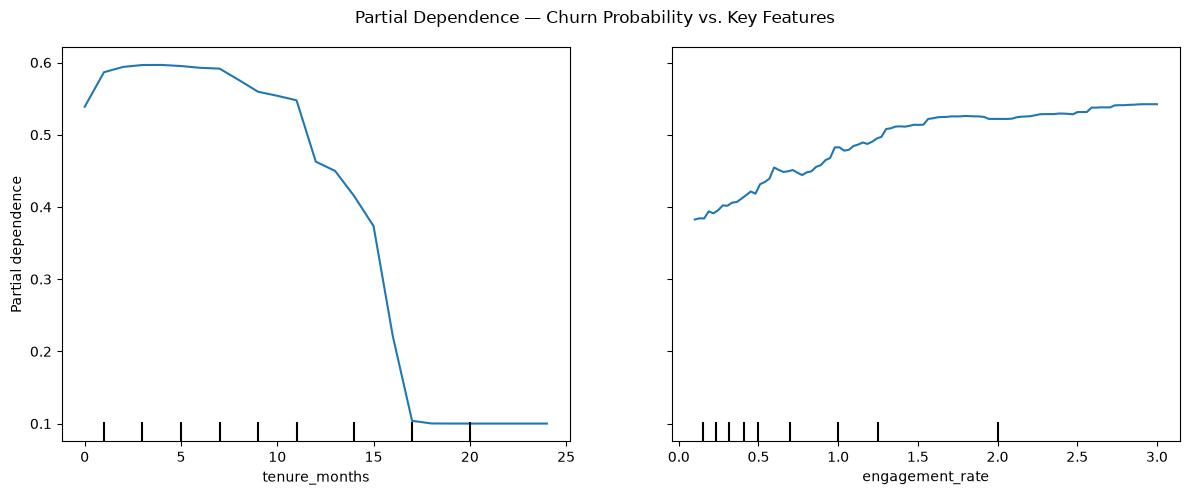

In [11]:
# Partial dependence plots - reveal the true shape/direction
# of engagement_rate and tenure_months' effect on churn probability.

from sklearn.inspection import PartialDependenceDisplay
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    churn_model_rf,
    X_train,
    features=['tenure_months', 'engagement_rate'],
    ax=ax
)
plt.suptitle('Partial Dependence — Churn Probability vs. Key Features')
plt.tight_layout()
plt.show()

tenure_months (left chart): now we see the real shape, which logistic regression's straight line was only crudely approximating. Churn risk stays consistently high (~55-60%) through the first ~11 months, then drops sharply between months 12-17, and flattens out to a low, stable ~10% after that. Customers who make it past roughly the one-year mark become dramatically stickier, almost like they've "graduated" out of the risk zone. That's a much stronger, more specific insight than "tenure is protective", now I can say "risk is concentrated in the first year, and drops off a cliff around month 12-17."

engagement_rate (right chart): the curve is still consistently upward-sloping across its entire range, in both the linear model and this non-linear one. That rules out my earlier hypothesis (a hidden non-linear "moderate is safest" shape), it's genuinely, consistently positive in this data, not a linear-model artifact.

So the real question becomes: why would higher engagement genuinely predict more churn here? Random Forest's default feature importance is known to be biased toward continuous, high-cardinality features like engagement_rate, even when the true relationship is weak or coincidental. It can overstate a feature's importance just because it has many possible values to split on, not because it's truly predictive.

Trying permutation importance, a more reliable, unbiased method. Instead of trusting the model's internal (and potentially biased) importance scores, permutation importance takes a more empirical approach: it takes one feature column, randomly shuffles its values (destroying any real relationship it had with the target), and measures how much the model's performance drops as a result. If shuffling a feature barely hurts performance, that feature wasn't really contributing much, regardless of what the biased internal importance score claimed.

In [12]:
# Permutation importance 
# model's built-in feature_importances_, which can be biased toward
# continuous/high-cardinality features like engagement_rate.

from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(
    churn_model_rf, X_test, y_test, 
    n_repeats=10,       # shuffle each feature 10 times and average, for stability
    random_state=42,
    scoring='recall'    # measure the drop in RECALL specifically, since that's
                         # the metric we actually care about for churn detection
)

permutation_importance_scores = pd.Series(
    permutation_results.importances_mean, index=feature_columns
).sort_values(ascending=False)

print("Permutation importance (drop in recall when feature is shuffled):")
print(permutation_importance_scores)

Permutation importance (drop in recall when feature is shuffled):
tenure_months           1.975556e-01
engagement_rate         1.333333e-02
crm_emails_clicked      6.666667e-04
plan_name_Enterprise    6.666667e-04
crm_emails_opened       2.220446e-17
plan_name_Pro           0.000000e+00
mrr                    -2.000000e-03
crm_emails_sent        -3.333333e-03
also_ecommerce         -5.111111e-03
total_events           -1.111111e-02
dtype: float64


That confirms it.

**`tenure_months`: 0.198** - shuffling it causes a massive ~20-point drop in recall. This is overwhelmingly the model's real driver, consistent with everything else.

**`engagement_rate`: 0.013** - shuffling it barely hurts performance at all (a tiny fraction of tenure's impact). This confirms my suspicion: the built-in importance (24%) was substantially **inflated by bias**, not reflecting genuine predictive power. Its true contribution is minor.

**Everything else (CRM engagement, plan type, MRR, cross-buying): essentially zero or even slightly negative** — meaning the model performs the same or marginally *better* without them. They're just noise.

## The final conclusion

After all this investigation - logistic regression, class rebalancing, feature normalization, Random Forest, partial dependence plots, and now permutation importance, my real, defensible finding is:

> **Tenure is the only strong churn signal in this dataset. Specifically, churn risk is concentrated in the first ~11 months and drops sharply between months 12-17. No other features shows a reliable, unbiased relationship with churn.**


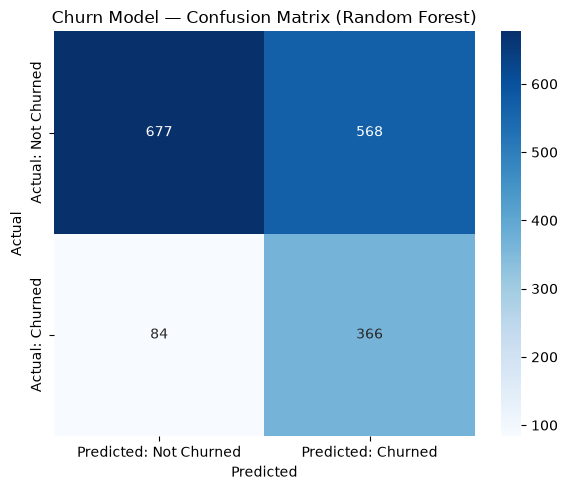

In [13]:
# Confusion matrix heatmap for the final model (Random Forest)

import matplotlib.pyplot as plt
import seaborn as sns

confusion_matrix_values = confusion_matrix(y_test, churn_predictions_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: Not Churned', 'Predicted: Churned'],
    yticklabels=['Actual: Not Churned', 'Actual: Churned']
)
plt.title('Churn Model — Confusion Matrix (Random Forest)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

366 true churners correctly caught vs. only 84 missed, at the cost of 568 false alarms (top-right). 

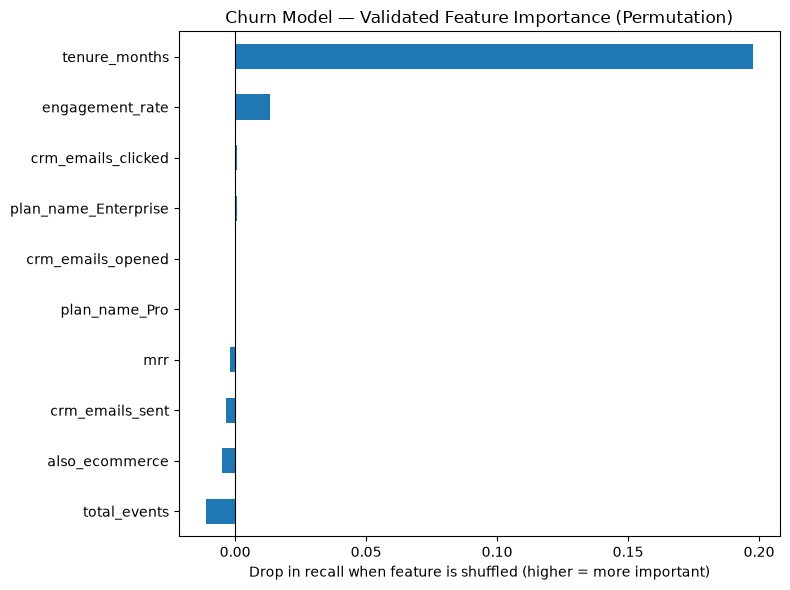

In [14]:
# Visualizing permutation importance - validated feature ranking

plt.figure(figsize=(8, 6))
permutation_importance_scores.sort_values().plot(kind='barh', color='#1f77b4')
plt.title('Churn Model — Validated Feature Importance (Permutation)')
plt.xlabel('Drop in recall when feature is shuffled (higher = more important)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Newer subscribers are far more likely to churn than long-tenured ones**, and specifically, it's not a smooth, gradual decline, it's more like a cliff. From the partial dependence plot: churn risk stays **high and roughly flat (~55-60%)** for roughly the first 11 months, then **drops sharply between months 12 and 17**, then stays **low and stable (~10%)** from there on.

SO,**if a subscriber survives to around the one-year mark, they become dramatically more likely to stay long-term.** The real risk window is that first year, that's when the vast majority of churn actually happens. After that, customers seem to have "proven" they're sticking around, and the model treats them as low-risk going forward.

It's more like a "survival curve" or "cohort maturation" effect, and it's exactly why several companies I know focus retention efforts heavily on onboarding and the first-year experience, rather than spreading retention budget evenly across all tenure levels.

In [15]:
# Save the trained churn model to disk for later use in batch scoring

import joblib

joblib.dump(churn_model_rf, 'churn_model.pkl')
joblib.dump(feature_columns, 'churn_model_features.pkl')  # save the exact feature list/order too

print("Churn model saved.")

Churn model saved.
